##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Downloading/Loading Oxford-IIIT Pet dataset...


100%|██████████| 792M/792M [00:03<00:00, 241MB/s]  
100%|██████████| 19.2M/19.2M [00:00<00:00, 97.7MB/s]


Extracting DINOv2 CLS tokens...
Running K-Means clustering...

✅ Clustering Accuracy: 100.00%
Generating PCA Visualization...


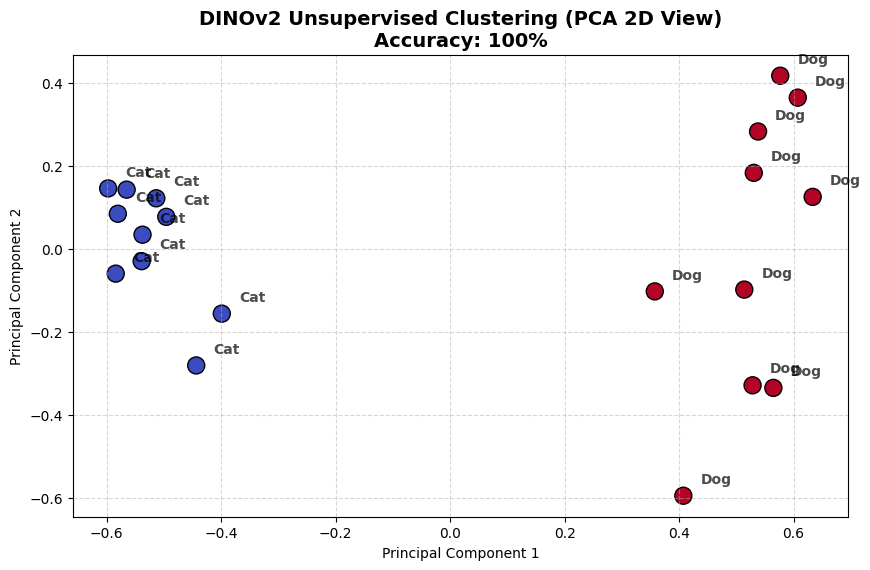

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel
from torchvision.datasets import OxfordIIITPet

# 1. Load DINOv2 Foundation Model
MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

# 2. Download and Extract 20 Images (10 Cats, 10 Dogs)
print("Downloading/Loading Oxford-IIIT Pet dataset...")
dataset = OxfordIIITPet(root="data/", download=True)

cat_breeds = ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 
              'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx']

images = []
true_labels = [] # "Cat" or "Dog"
numeric_labels = [] # 0 for Cat, 1 for Dog
cat_count, dog_count = 0, 0

for img, target in dataset:
    class_name = dataset.classes[target]
    is_cat = class_name in cat_breeds
    
    if is_cat and cat_count < 10:
        images.append(img.convert("RGB"))
        true_labels.append("Cat")
        numeric_labels.append(0)
        cat_count += 1
    elif not is_cat and dog_count < 10:
        images.append(img.convert("RGB"))
        true_labels.append("Dog")
        numeric_labels.append(1)
        dog_count += 1
        
    if cat_count == 10 and dog_count == 10:
        break

# 3. Extract Global [CLS] Embeddings
print("Extracting DINOv2 CLS tokens...")
embeddings = []
for img in images:
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        cls_token = outputs.last_hidden_state[:, 0]
        normalized_token = F.normalize(cls_token, p=2, dim=1)
        embeddings.append(normalized_token.cpu().numpy())

embeddings = np.vstack(embeddings)

# 4. Run K-Means Clustering
print("Running K-Means clustering...")
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
predicted_clusters = kmeans.fit_predict(embeddings)

# 5. Calculate Accuracy
# Since unsupervised clustering might assign '0' to Dogs and '1' to Cats, we check both mappings
numeric_labels = np.array(numeric_labels)
acc1 = np.mean(predicted_clusters == numeric_labels)
acc2 = np.mean(predicted_clusters == (1 - numeric_labels))
accuracy = max(acc1, acc2) * 100
print(f"\n✅ Clustering Accuracy: {accuracy:.2f}%")

# 6. Visualize with PCA
print("Generating PCA Visualization...")
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
# Plot the points, colored by their predicted cluster
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                      c=predicted_clusters, cmap='coolwarm', s=150, edgecolors='black')

# Label each dot with its true identity (Cat or Dog)
for i, txt in enumerate(true_labels):
    plt.annotate(txt, (reduced_embeddings[i, 0] + 0.03, reduced_embeddings[i, 1] + 0.03), 
                 fontsize=10, fontweight='bold', alpha=0.7)

plt.title(f"DINOv2 Unsupervised Clustering (PCA 2D View)\nAccuracy: {accuracy:.0f}%", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading DINOv2 ImageNet-1k classification model...


Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Fetching test image from GitHub...


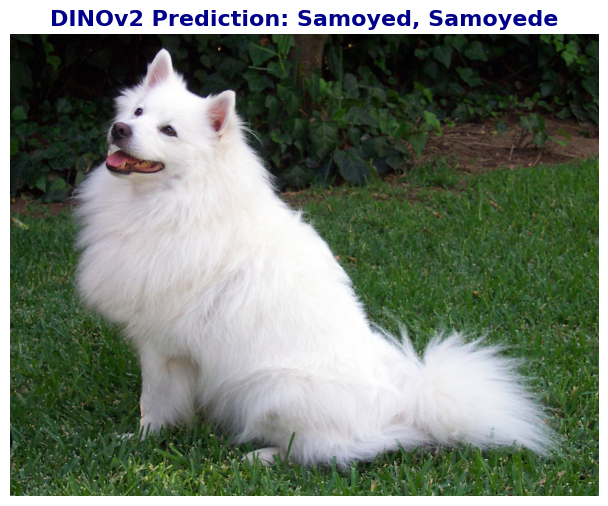

In [ ]:
import torch
import requests
import io
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

# 1. Load DINOv2 Classification Model
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading DINOv2 ImageNet-1k classification model...")
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
model.eval()

# 2. Download an ImageNet-1k testing image (Samoyed Dog)
print("Fetching test image from GitHub...")
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

response = requests.get(url)
if response.status_code != 200:
    print(f"🚨 Failed to download image. Status code: {response.status_code}")
else:
    image = Image.open(io.BytesIO(response.content)).convert("RGB")
# -------------------------------------------------------------

# 3. Run Inference
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    # The highest logit score is the model's prediction
    predicted_class_idx = logits.argmax(-1).item()

# Map the raw index ID to the human-readable class name
predicted_label = model.config.id2label[predicted_class_idx]

# 4. Visualize the Result
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title(f"DINOv2 Prediction: {predicted_label}", fontsize=16, fontweight='bold', color='darkblue')
plt.axis('off')
plt.show()